True Integral Value: 0.8862269254527579

--- Simple Sampling ---
Simple Sampling Integral Estimate: 0.8902837881502424
Simple Sampling Error: 0.004056862697484509


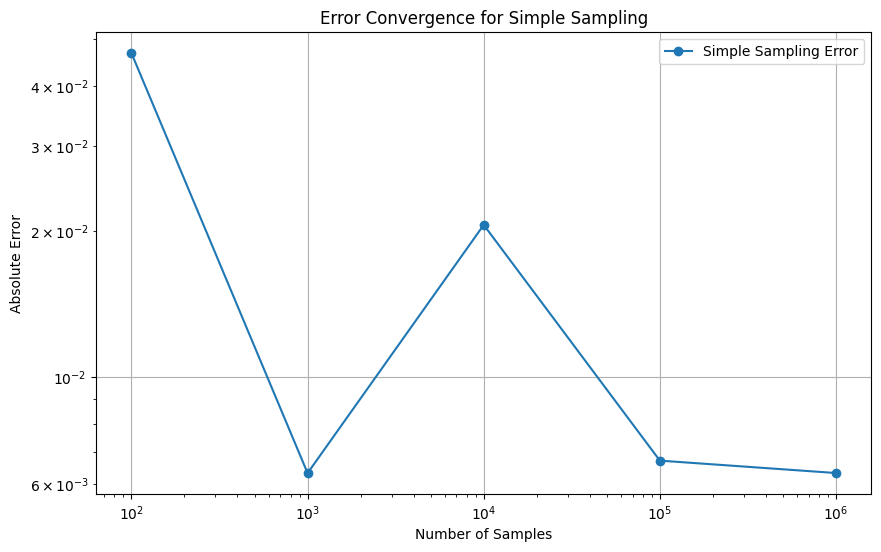

In [8]:
# Integrate I=∫010​e−x2dx using simple sampling and importance sampling.

import numpy as np
import matplotlib.pyplot as plt

# Define the function to integrate
def f(x):
    return np.exp(-x**2)

# Calculate the true value of the integral
true_value = np.sqrt(np.pi) / 2  # Analytical result for ∫₀¹ e^(-x²) dx
print(f"True Integral Value: {true_value}")

print("\n--- Simple Sampling ---")
# Simple sampling
def simple_sampling_integral(n_samples):
    samples = np.random.uniform(0, 10, n_samples)
    estimates = f(samples)

    return 10 * np.mean(estimates)

simple_sampling_integral_value = simple_sampling_integral(1000000)
print(f"Simple Sampling Integral Estimate: {simple_sampling_integral_value}")

def absolute_error(estimate, true_value):
    return abs(estimate - true_value)

# Estimate the error
simple_sampling_error = absolute_error(simple_sampling_integral_value, true_value)
print(f"Simple Sampling Error: {simple_sampling_error}")

# Plot the error convergence for simple sampling
n_samples_list = [100, 1000, 10000, 100000, 1000000]
errors_simple = [absolute_error(simple_sampling_integral(n), true_value) for n in n_samples_list]
plt.figure(figsize=(10, 6))
plt.loglog(n_samples_list, errors_simple, marker='o', label='Simple Sampling Error')
plt.xlabel('Number of Samples')
plt.ylabel('Absolute Error')
plt.title('Error Convergence for Simple Sampling')
plt.grid()
plt.legend()
plt.show()


In [ ]:
# Importance sampling

print("\n--- Importance Sampling ---")
px = lambda x: np.exp(-x)  # Exponential distribution with rate parameter 1


def importance_sampling_integral(n_samples):
    # Generate samples from exponential distribution with rate parameter 1
    samples = np.random.exponential(1, n_samples)
    # Keep only samples within [0, 10]
    samples = samples[samples <= 10]
    # Compute the estimator
    weights = np.exp(-samples**2 + samples)  # e^(-x_i^2 + x_i)
    return np.mean(weights)